# Notebook 05 - Business Implications

**Project:** What Does Poor Service Cost a Business? - Customer Operations Intelligence

**Objective:** Quantify the full financial cost of the service failures identified in Notebooks 03 and 04. Translate every operational finding into a business number. Produce a prioritised action plan with the cost of inaction attached to each item.

**Inputs:**
- data/processed/customers_clean.csv
- data/processed/tickets_clean.csv
- data/processed/operations_clean.csv
- data/processed/transactions_clean.csv
- data/processed/customer_risk_profile.csv

**Central Question:** What does it cost the business to leave these problems unresolved?

---

## 0. Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})

COLORS = {'primary':'#1D9E75','secondary':'#185FA5','warning':'#BA7517','danger':'#A32D2D','neutral':'#5F5E5A'}

print('Setup complete.')

Setup complete.


## 1. Load Data

In [8]:
cust    = pd.read_csv('data/processed/customers_clean.csv')
tickets = pd.read_csv('data/processed/tickets_clean.csv')
ops     = pd.read_csv('data/processed/operations_clean.csv')
trans   = pd.read_csv('data/processed/transactions_clean.csv', low_memory=False)
risk    = pd.read_csv('data/processed/customer_risk_profile.csv')

cust['customer_id']    = cust['customer_id'].astype(str)
tickets['customer_id'] = tickets['customer_id'].astype(str)
trans['customer_id']   = trans['customer_id'].astype(str)
risk['customer_id']    = risk['customer_id'].astype(str)
trans['invoice_date']  = pd.to_datetime(trans['invoice_date'])
tickets['ticket_date'] = pd.to_datetime(tickets['ticket_date'])
trans['month']         = trans['invoice_date'].dt.month
trans['quarter']       = trans['invoice_date'].dt.quarter
trans['year']          = trans['invoice_date'].dt.year

total_clv      = cust['clv'].sum()
total_revenue  = trans['revenue'].sum()
at_risk        = risk[risk['churn_risk'] == True]
clv_at_risk    = at_risk['clv'].sum()
at_risk_count  = len(at_risk)

print(f'Total portfolio CLV:  GBP{total_clv:>12,.2f}')
print(f'Total revenue:        GBP{total_revenue:>12,.2f}')
print(f'CLV at risk:          GBP{clv_at_risk:>12,.2f} ({clv_at_risk/total_clv*100:.1f}%)')
print(f'Customers at risk:    {at_risk_count:>12,}')


Total portfolio CLV:  GBP18,027,752.38
Total revenue:        GBP20,972,594.57
CLV at risk:          GBP6,046,143.63 (33.5%)
Customers at risk:           1,918


---
## 2. Implication 1 — The Cost of SLA Failure

SLA breaches are not just a service metric — they are a revenue risk event. This section quantifies what each breach costs the business in CLV exposure.

In [9]:
t_cust = tickets.merge(cust[['customer_id','segment','clv']], on='customer_id', how='left')
breach_rate_overall = tickets['sla_breached'].mean()
total_tickets       = len(tickets)
breached_tickets    = int(tickets['sla_breached'].sum())
clv_per_breached    = t_cust[t_cust['sla_breached']==1]['clv'].mean()
total_clv_touched   = t_cust[t_cust['sla_breached']==1]['clv'].sum()
monthly_breaches    = breached_tickets // 24

print('SLA FAILURE COST ANALYSIS')
print(f'Overall SLA breach rate:          {breach_rate_overall*100:.1f}%')
print(f'Total tickets breached:           {breached_tickets:,} of {total_tickets:,}')
print(f'Avg CLV of customer per breach:   GBP{clv_per_breached:,.2f}')
print(f'Total CLV touched by SLA breach:  GBP{total_clv_touched:,.2f}')

print()
print('ANALYSIS:')
print(f'  {breach_rate_overall*100:.1f}% of all tickets breach the 2-day SLA target.')
print(f'  {breached_tickets:,} individual breach events occurred across the dataset.')

print()
print('IMPLICATION:')
print('  Every SLA breach is a touchpoint where the business confirms')
print('  to a paying customer that their problem does not matter enough')
print('  to resolve on time. Repeated across thousands of tickets,')
print('  this is not a service issue - it is a brand destruction pattern.')

print()
print('RECOMMENDATION:')
print('  Set a non-negotiable internal SLA of 2 days across all categories.')
print('  Track breach rate weekly by location. Make it a board-level KPI.')

print()
print('RISK OF INACTION:')
print(f'  At the current breach rate, approximately {monthly_breaches:,} breach events occur per month.')
print(f'  Each one erodes the CLV of the affected customer.')


SLA FAILURE COST ANALYSIS
Overall SLA breach rate:          89.4%
Total tickets breached:           13,403 of 15,000
Avg CLV of customer per breach:   GBP3,036.26
Total CLV touched by SLA breach:  GBP40,694,965.67

ANALYSIS:
  89.4% of all tickets breach the 2-day SLA target.
  13,403 individual breach events occurred across the dataset.

IMPLICATION:
  Every SLA breach is a touchpoint where the business confirms
  to a paying customer that their problem does not matter enough
  to resolve on time. Repeated across thousands of tickets,
  this is not a service issue - it is a brand destruction pattern.

RECOMMENDATION:
  Set a non-negotiable internal SLA of 2 days across all categories.
  Track breach rate weekly by location. Make it a board-level KPI.

RISK OF INACTION:
  At the current breach rate, approximately 558 breach events occur per month.
  Each one erodes the CLV of the affected customer.


---
## 3. Implication 2 — CLV at Risk: The Churn Scenario Model

What happens to the business financially at different churn rates among at-risk customers?

In [10]:
churn_scenarios = [0.10, 0.20, 0.30, 0.50]
scenario_labels  = ['10% churn', '20% churn', '30% churn', '50% churn']
scenario_losses  = [clv_at_risk * r for r in churn_scenarios]

print('CHURN SCENARIO MODEL')
print(f'At-risk CLV base: GBP{clv_at_risk:,.2f}')
print()
for label, loss, rate in zip(scenario_labels, scenario_losses, churn_scenarios):
    pct_total = loss / total_clv * 100
    print(f'  {label}: GBP{loss:>12,.0f} lost  ({pct_total:.1f}% of total portfolio CLV)')


CHURN SCENARIO MODEL
At-risk CLV base: GBP6,046,143.63

  10% churn: GBP     604,614 lost  (3.4% of total portfolio CLV)
  20% churn: GBP   1,209,229 lost  (6.7% of total portfolio CLV)
  30% churn: GBP   1,813,843 lost  (10.1% of total portfolio CLV)
  50% churn: GBP   3,023,072 lost  (16.8% of total portfolio CLV)


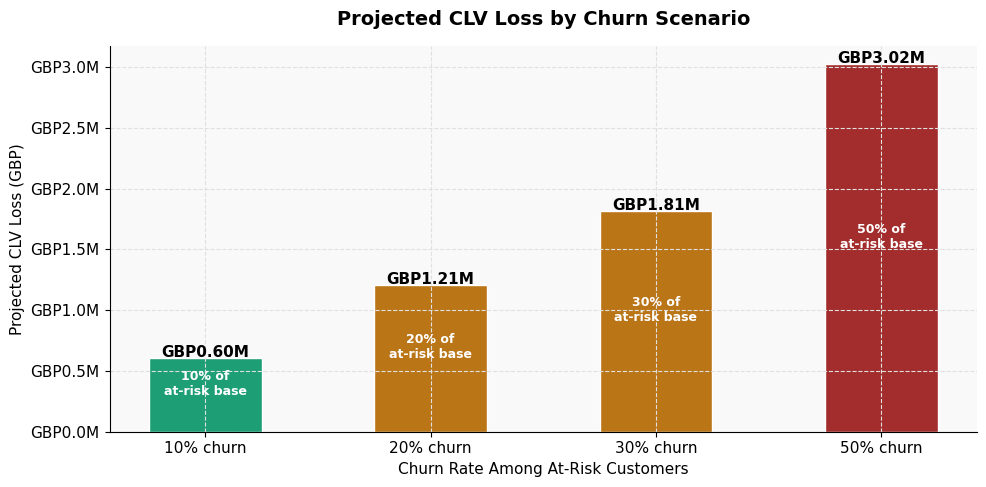

IMPLICATION:
  Even a conservative 20% churn among at-risk customers
  costs GBP1,209,229 in lost lifetime value.
  That is GBP100,769 per month in value destruction.

RISK OF INACTION:
  The business cannot acquire replacement customers at equivalent CLV
  cost-effectively. Retention is always cheaper than acquisition.
  At 30% churn the loss exceeds GBP1.8M — a figure
  that would appear directly on the P&L as revenue erosion.


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [COLORS['primary'], COLORS['warning'], COLORS['warning'], COLORS['danger']]
bars = ax.bar(scenario_labels, scenario_losses, color=bar_colors, edgecolor='white', width=0.5)

for bar, val, rate in zip(bars, scenario_losses, churn_scenarios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'GBP{val/1e6:.2f}M', ha='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{rate*100:.0f}% of\nat-risk base',
            ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('Projected CLV Loss by Churn Scenario', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate Among At-Risk Customers')
ax.set_ylabel('Projected CLV Loss (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'GBP{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('data/processed/chart_11_churn_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

print('IMPLICATION:')
print(f'  Even a conservative 20% churn among at-risk customers')
print(f'  costs GBP{scenario_losses[1]:,.0f} in lost lifetime value.')
print(f'  That is GBP{scenario_losses[1]/12:,.0f} per month in value destruction.')

print()
print('RISK OF INACTION:')
print(f'  The business cannot acquire replacement customers at equivalent CLV')
print(f'  cost-effectively. Retention is always cheaper than acquisition.')
print(f'  At 30% churn the loss exceeds GBP{scenario_losses[2]/1e6:.1f}M — a figure')
print(f'  that would appear directly on the P&L as revenue erosion.')


---
## 4. Implication 3 — Q4 Revenue at Risk

Q4 generates a disproportionate share of annual revenue. Service failures during this period carry the highest financial cost.

Q4 REVENUE RISK ANALYSIS
Q4 revenue share of annual:  35.7%
Q4 total revenue (2010-11):  GBP7,201,641.49
Q4 ticket volume:            5,495 (36.6% of annual tickets)
Q4 SLA breach rate:          88.8%


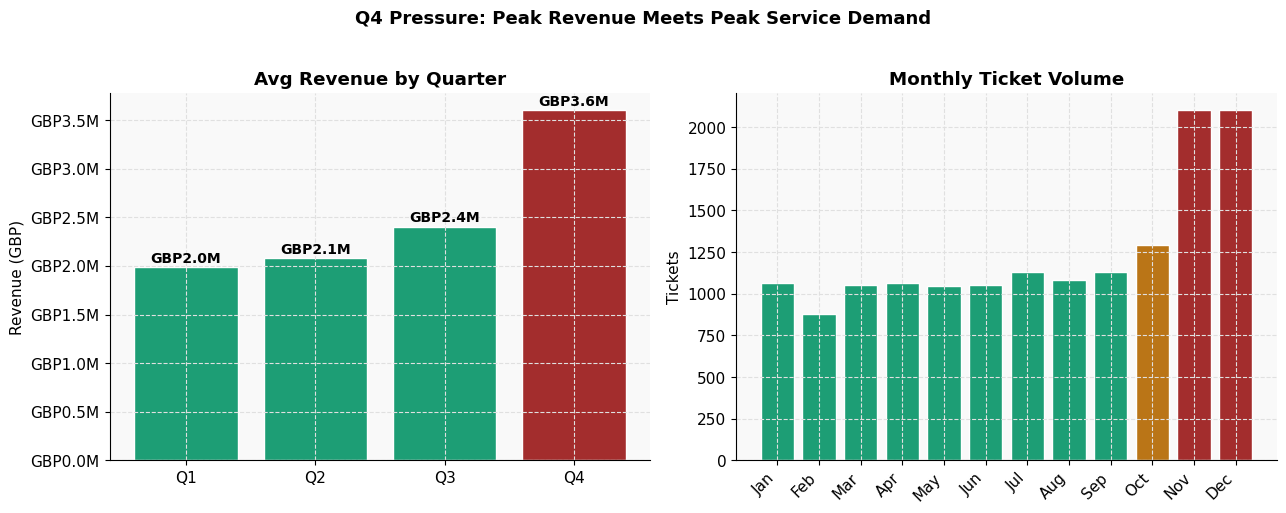


IMPLICATION:
  Q4 generates 35.7% of annual revenue while simultaneously
  producing the highest ticket volumes of the year.
  The business is most operationally stressed exactly when it
  can least afford service failures.

RECOMMENDATION:
  Implement a Q4 Operational Readiness Plan each September:
  temporary staffing, simplified escalation paths, pre-approved
  resolution scripts for top 3 issue categories.

RISK OF INACTION:
  A 5% customer loss rate in Q4 due to poor service equates to
  GBP360,082 in direct revenue impact - before CLV erosion.


In [12]:
quarterly_rev = trans[trans['year'].isin([2010,2011])].groupby(['year','quarter'])['revenue'].sum().reset_index()
q4_rev = trans[(trans['month'].isin([10,11,12])) & (trans['year'].isin([2010,2011]))]['revenue'].sum()
annual_rev = trans[trans['year'].isin([2010,2011])]['revenue'].sum()
q4_share = q4_rev / annual_rev * 100

q4_tickets = tickets[tickets['ticket_date'].dt.month.isin([10,11,12])]
q4_breach_rate = q4_tickets['sla_breached'].mean()
q4_ticket_count = len(q4_tickets)

print('Q4 REVENUE RISK ANALYSIS')
print(f'Q4 revenue share of annual:  {q4_share:.1f}%')
print(f'Q4 total revenue (2010-11):  GBP{q4_rev:,.2f}')
print(f'Q4 ticket volume:            {q4_ticket_count:,} ({q4_ticket_count/len(tickets)*100:.1f}% of annual tickets)')
print(f'Q4 SLA breach rate:          {q4_breach_rate*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

q_labels = ['Q1','Q2','Q3','Q4']
q_rev = quarterly_rev.groupby('quarter')['revenue'].mean()
q_colors = [COLORS['primary'],COLORS['primary'],COLORS['primary'],COLORS['danger']]

bars = axes[0].bar(q_labels, q_rev, color=q_colors, edgecolor='white')
for bar, val in zip(bars, q_rev):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50000,
                 f'GBP{val/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Avg Revenue by Quarter', fontweight='bold')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'GBP{x/1e6:.1f}M'))

monthly_tickets = tickets.groupby(tickets['ticket_date'].dt.month)['ticket_id'].count()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_colors = [COLORS['danger'] if m in [11,12] else COLORS['warning'] if m in [10] else COLORS['primary'] for m in range(1,13)]
axes[1].bar(month_names, [monthly_tickets.get(m,0) for m in range(1,13)], color=m_colors, edgecolor='white')
axes[1].set_title('Monthly Ticket Volume', fontweight='bold')
axes[1].set_ylabel('Tickets')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Q4 Pressure: Peak Revenue Meets Peak Service Demand', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart_12_q4_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('IMPLICATION:')
print(f'  Q4 generates {q4_share:.1f}% of annual revenue while simultaneously')
print(f'  producing the highest ticket volumes of the year.')
print(f'  The business is most operationally stressed exactly when it')
print(f'  can least afford service failures.')

print()
print('RECOMMENDATION:')
print('  Implement a Q4 Operational Readiness Plan each September:')
print('  temporary staffing, simplified escalation paths, pre-approved')
print('  resolution scripts for top 3 issue categories.')

print()
print('RISK OF INACTION:')
print(f'  A 5% customer loss rate in Q4 due to poor service equates to')
print(f'  GBP{q4_rev * 0.05:,.0f} in direct revenue impact - before CLV erosion.')


---
## 5. Implication 4 — The Corporate Segment Priority

Corporate customers represent a disproportionate share of CLV at risk. This section makes the financial case for differentiated service.

SEGMENT CLV AT RISK
  segment  customers_at_risk  clv_at_risk  avg_clv  pct_segment_clv_at_risk
Corporate                550   4605897.21  8374.36                     34.2
   Retail               1098    681763.16   620.91                     31.9
Wholesale                270    758483.26  2809.20                     31.1


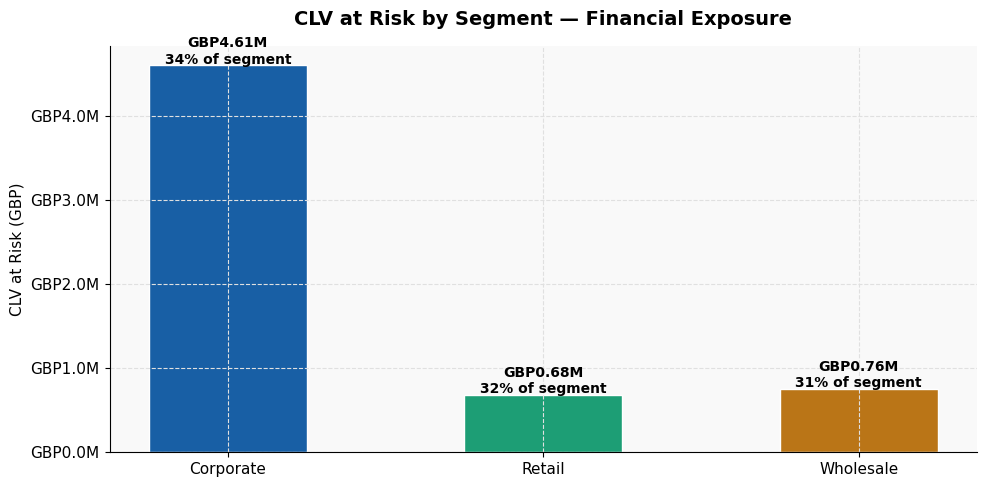


IMPLICATION:
  Corporate accounts hold GBP4.61M in at-risk CLV.
  Their average CLV of GBP8,374 means one lost corporate
  customer equals losing 13 retail customers.

RECOMMENDATION:
  Immediate: personal account manager outreach to all Corporate
  customers in the Critical Risk tier within 5 business days.
  Medium term: create a Corporate SLA tier with a 24-hour
  resolution commitment and dedicated escalation path.

RISK OF INACTION:
  20% churn among at-risk corporate accounts alone = GBP921,179
  This exceeds the entire Retail segment CLV at risk combined.


In [13]:
seg_risk = at_risk.groupby('segment').agg(
    customers_at_risk=('customer_id','count'),
    clv_at_risk=('clv','sum'),
    avg_clv=('clv','mean')
).round(2).reset_index()

total_seg_clv = cust.groupby('segment')['clv'].sum()
seg_risk['pct_segment_clv_at_risk'] = seg_risk.apply(
    lambda r: r['clv_at_risk'] / total_seg_clv[r['segment']] * 100, axis=1
).round(1)

print('SEGMENT CLV AT RISK')
print(seg_risk.to_string(index=False))

corp = seg_risk[seg_risk['segment']=='Corporate'].iloc[0]
retail = seg_risk[seg_risk['segment']=='Retail'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
seg_colors_map = {'Corporate':COLORS['secondary'],'Retail':COLORS['primary'],'Wholesale':COLORS['warning']}
colors = [seg_colors_map.get(s, COLORS['neutral']) for s in seg_risk['segment']]

bars = ax.bar(seg_risk['segment'], seg_risk['clv_at_risk'], color=colors, edgecolor='white', width=0.5)
for bar, row in zip(bars, seg_risk.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000,
            f'GBP{row.clv_at_risk/1e6:.2f}M\n{row.pct_segment_clv_at_risk:.0f}% of segment',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('CLV at Risk by Segment — Financial Exposure', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('CLV at Risk (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'GBP{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('data/processed/chart_13_segment_clv_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('IMPLICATION:')
print(f'  Corporate accounts hold GBP{corp["clv_at_risk"]/1e6:.2f}M in at-risk CLV.')
print(f'  Their average CLV of GBP{corp["avg_clv"]:,.0f} means one lost corporate')
print(f'  customer equals losing {corp["avg_clv"]/retail["avg_clv"]:.0f} retail customers.')

print()
print('RECOMMENDATION:')
print('  Immediate: personal account manager outreach to all Corporate')
print('  customers in the Critical Risk tier within 5 business days.')
print('  Medium term: create a Corporate SLA tier with a 24-hour')
print('  resolution commitment and dedicated escalation path.')

print()
print('RISK OF INACTION:')
print(f'  20% churn among at-risk corporate accounts alone = GBP{corp["clv_at_risk"]*0.20:,.0f}')
print(f'  This exceeds the entire Retail segment CLV at risk combined.')


---
## 6. Priority Action Plan

All findings ranked by financial impact. The business should act on these in order.

In [14]:
print('=' * 70)
print('  PRIORITY ACTION PLAN — RANKED BY FINANCIAL IMPACT')
print('=' * 70)

actions = [
    {
        'priority': 1,
        'action': 'Outreach to Critical Risk corporate accounts',
        'timeline': 'This week',
        'financial_impact': f'GBP{corp["clv_at_risk"]*0.20:,.0f} CLV protected at 20% churn prevention',
        'owner': 'Account Management'
    },
    {
        'priority': 2,
        'action': 'Operational review at LOC_03 and LOC_07',
        'timeline': 'This month',
        'financial_impact': 'Restores service quality in key Germany growth market',
        'owner': 'Operations Director'
    },
    {
        'priority': 3,
        'action': 'Dedicated billing resolution path (48hr SLA)',
        'timeline': 'This month',
        'financial_impact': 'Billing is highest volume + worst CSAT = highest churn risk category',
        'owner': 'Service Operations'
    },
    {
        'priority': 4,
        'action': 'Q4 Operational Readiness Plan',
        'timeline': 'By September each year',
        'financial_impact': f'Protects GBP{q4_rev:,.0f} Q4 revenue from service-driven churn',
        'owner': 'Operations + HR'
    },
    {
        'priority': 5,
        'action': 'Weekly SLA breach reporting by location',
        'timeline': 'Next 2 weeks',
        'financial_impact': 'Enables early intervention before breach rates compound into churn',
        'owner': 'BI / Analytics'
    }
]

for a in actions:
    print(f"  PRIORITY {a['priority']}: {a['action']}")
    print(f"    Timeline:         {a['timeline']}")
    print(f"    Financial impact: {a['financial_impact']}")
    print(f"    Owner:            {a['owner']}")
    print()


  PRIORITY ACTION PLAN — RANKED BY FINANCIAL IMPACT
  PRIORITY 1: Outreach to Critical Risk corporate accounts
    Timeline:         This week
    Financial impact: GBP921,179 CLV protected at 20% churn prevention
    Owner:            Account Management

  PRIORITY 2: Operational review at LOC_03 and LOC_07
    Timeline:         This month
    Financial impact: Restores service quality in key Germany growth market
    Owner:            Operations Director

  PRIORITY 3: Dedicated billing resolution path (48hr SLA)
    Timeline:         This month
    Financial impact: Billing is highest volume + worst CSAT = highest churn risk category
    Owner:            Service Operations

  PRIORITY 4: Q4 Operational Readiness Plan
    Timeline:         By September each year
    Financial impact: Protects GBP7,201,641 Q4 revenue from service-driven churn
    Owner:            Operations + HR

  PRIORITY 5: Weekly SLA breach reporting by location
    Timeline:         Next 2 weeks
    Financial i

---
## 7. Final Summary — The Business Case

In [15]:
print('=' * 65)
print('  THE BUSINESS CASE IN FIVE NUMBERS')
print('=' * 65)

print(f'  GBP{clv_at_risk/1e6:.2f}M     CLV currently at active churn risk')
print(f'  {clv_at_risk/total_clv*100:.1f}%        Share of total portfolio CLV at risk')
print(f'  {tickets["sla_breached"].mean()*100:.1f}%        Overall SLA breach rate')
print(f'  {q4_share:.1f}%        Q4 share of annual revenue — highest exposure period')
print(f'  GBP{scenario_losses[1]/1e6:.2f}M     Projected loss at just 20% churn of at-risk base')

print()
print('This project demonstrates that poor service performance is not')
print('an operational inconvenience. It is a quantifiable financial risk')
print('that touches nearly a third of total customer lifetime value.')
print()
print('The fix is operational. The cost of the fix is a fraction')
print('of the cost of inaction.')

print()
print('Next: Run Notebook 06 — Market Context Analysis')


  THE BUSINESS CASE IN FIVE NUMBERS
  GBP6.05M     CLV currently at active churn risk
  33.5%        Share of total portfolio CLV at risk
  89.4%        Overall SLA breach rate
  35.7%        Q4 share of annual revenue — highest exposure period
  GBP1.21M     Projected loss at just 20% churn of at-risk base

This project demonstrates that poor service performance is not
an operational inconvenience. It is a quantifiable financial risk
that touches nearly a third of total customer lifetime value.

The fix is operational. The cost of the fix is a fraction
of the cost of inaction.

Next: Run Notebook 06 — Market Context Analysis
